In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mne
from pathlib import Path
import warnings
import importlib

import data_loader
importlib.reload(data_loader)
from data_loader import EEGDataLoader, get_default_data_path

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Exploratory Data Analysis

## 1. Load Data

In [2]:
data_path = get_default_data_path()
print(f"Data path: {data_path}")
loader = EEGDataLoader(str(data_path))

Data path: c:\Users\kamil\Documents\github\neuron\lie-detector\DATA\lie-detector
Found 17 participants


In [3]:
summary_df = loader.create_summary_dataframe()
print(f"Total participants: {len(summary_df)}\n")
display(summary_df)

Total participants: 17



,participant_id,n_files,honest_true,deceitful_true,honest_fake,deceitful_fake
0,02F6BC66,4,True,True,True,True
1,1299BF1A,4,True,True,True,True
2,2D663E30,4,True,True,True,True
3,4C0F44CF,4,True,True,True,True
4,6A517891 - stare dane,4,True,True,True,True
5,827366EC,4,True,True,True,True
6,8DB745E3,4,True,True,True,True
7,A3627947,4,True,True,True,True
8,ASD6DSA7,4,True,True,True,True
9,BNFH348D,4,True,True,True,True


In [4]:
block_columns = ['honest_true', 'deceitful_true', 'honest_fake', 'deceitful_fake']
completeness = summary_df[block_columns].sum()

print("Block availability:")
for block, count in completeness.items():
    percentage = (count / len(summary_df)) * 100
    print(f"  {block}: {count}/{len(summary_df)} ({percentage:.1f}%)")

complete_participants = summary_df[summary_df[block_columns].all(axis=1)]
print(f"\nParticipants with all 4 blocks: {len(complete_participants)}")

Block availability:
  honest_true: 17/17 (100.0%)
  deceitful_true: 17/17 (100.0%)
  honest_fake: 17/17 (100.0%)
  deceitful_fake: 17/17 (100.0%)

Participants with all 4 blocks: 17


## 2. Inspect Single Participant Data

In [5]:
if len(complete_participants) > 0:
    example_participant = complete_participants.iloc[0]['participant_id']
else:
    example_participant = loader.participants[0]

print(f"Loading data for participant: {example_participant}")
participant_data = loader.load_participant_data(example_participant)

Loading data for participant: 02F6BC66
  Loaded honest_true: 74575 samples, 21 channels, 250.0 Hz
  Loaded deceitful_true: 82275 samples, 21 channels, 250.0 Hz
  Loaded honest_fake: 79525 samples, 21 channels, 250.0 Hz
  Loaded deceitful_fake: 78625 samples, 21 channels, 250.0 Hz


In [6]:
first_block = list(participant_data.keys())[0]
raw = participant_data[first_block]

print(f"Recording Info - {first_block}")
print(f"  Sampling frequency: {raw.info['sfreq']} Hz")
print(f"  Number of channels: {len(raw.ch_names)}")
print(f"  Channel names: {raw.ch_names}")
print(f"  Duration: {raw.times[-1]:.2f} seconds")
print(f"  Total samples: {raw.n_times}")

Recording Info - honest_true
  Sampling frequency: 250.0 Hz
  Number of channels: 21
  Channel names: ['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2', 'T3', 'T4', 'T5', 'T6', 'F7', 'F8', 'Accel_x', 'Accel_y', 'Accel_z', 'Digital', 'Sample']
  Duration: 298.30 seconds
  Total samples: 74575


In [7]:
events, event_id = loader.get_events_from_raw(raw)

print(f"\nEvent Information:")
print(f"  Total events: {len(events)}")
print(f"  Event types: {len(event_id)}")
print(f"\nEvent types and counts:")

event_counts = pd.Series([sum(events[:, 2] == id_) for id_ in event_id.values()],
                        index=event_id.keys())
display(event_counts)


Event Information:
  Total events: 216
  Event types: 11

Event types and counts:


ParticipantResponse.NO                                      54
ParticipantResponse.YES                                     54
PersonalDataField.BIRTH_DATE: PersonalDataType.CELEBRITY     3
PersonalDataField.BIRTH_DATE: PersonalDataType.RANDO        18
PersonalDataField.BIRTH_DATE: PersonalDataType.REAL         15
PersonalDataField.HOMETOWN: PersonalDataType.CELEBRITY       3
PersonalDataField.HOMETOWN: PersonalDataType.RANDO          18
PersonalDataField.HOMETOWN: PersonalDataType.REAL           15
PersonalDataField.NAME: PersonalDataType.CELEBRITY           3
PersonalDataField.NAME: PersonalDataType.RANDO              18
PersonalDataField.NAME: PersonalDataType.REAL               15
dtype: int64

## 3. Visualize Raw Signals

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 30 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 0.10, 30.00 Hz: -6.02, -6.02 dB

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

IIR filter parameters
---------------------
Butterworth bandstop zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 49.38, 50.62 Hz: -6.02, -6.02 dB

FILTERED DATA (0.1-30 Hz bandpass + 50 Hz notch)
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Using matplotlib as 2D backend.


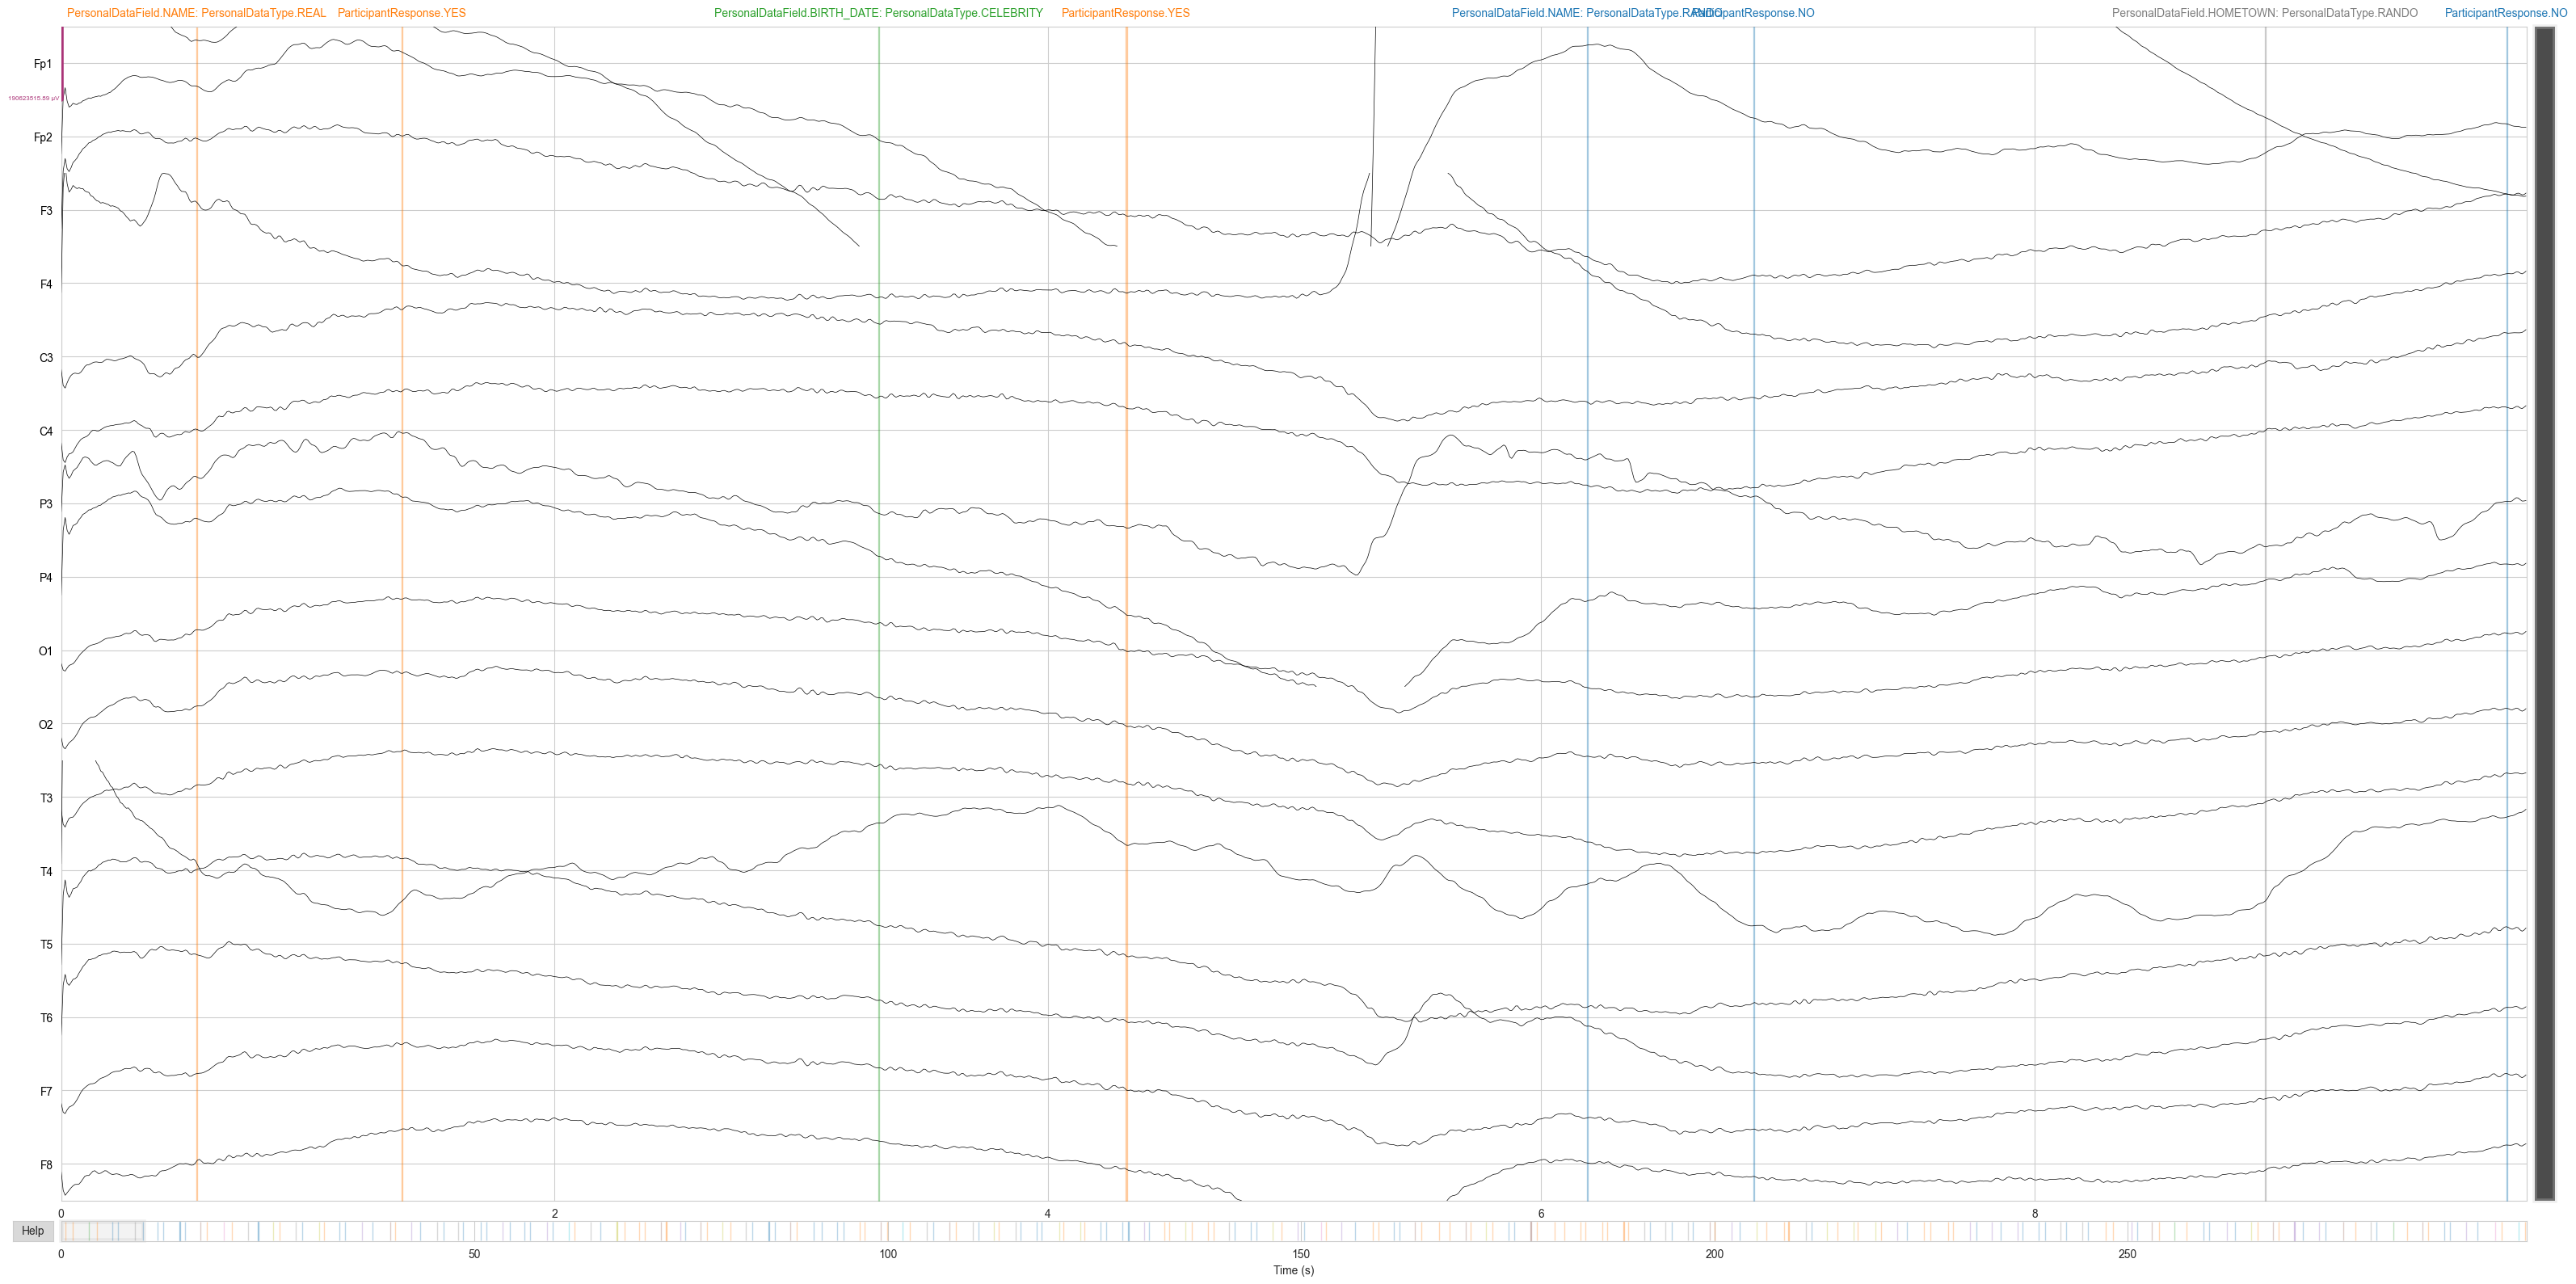

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


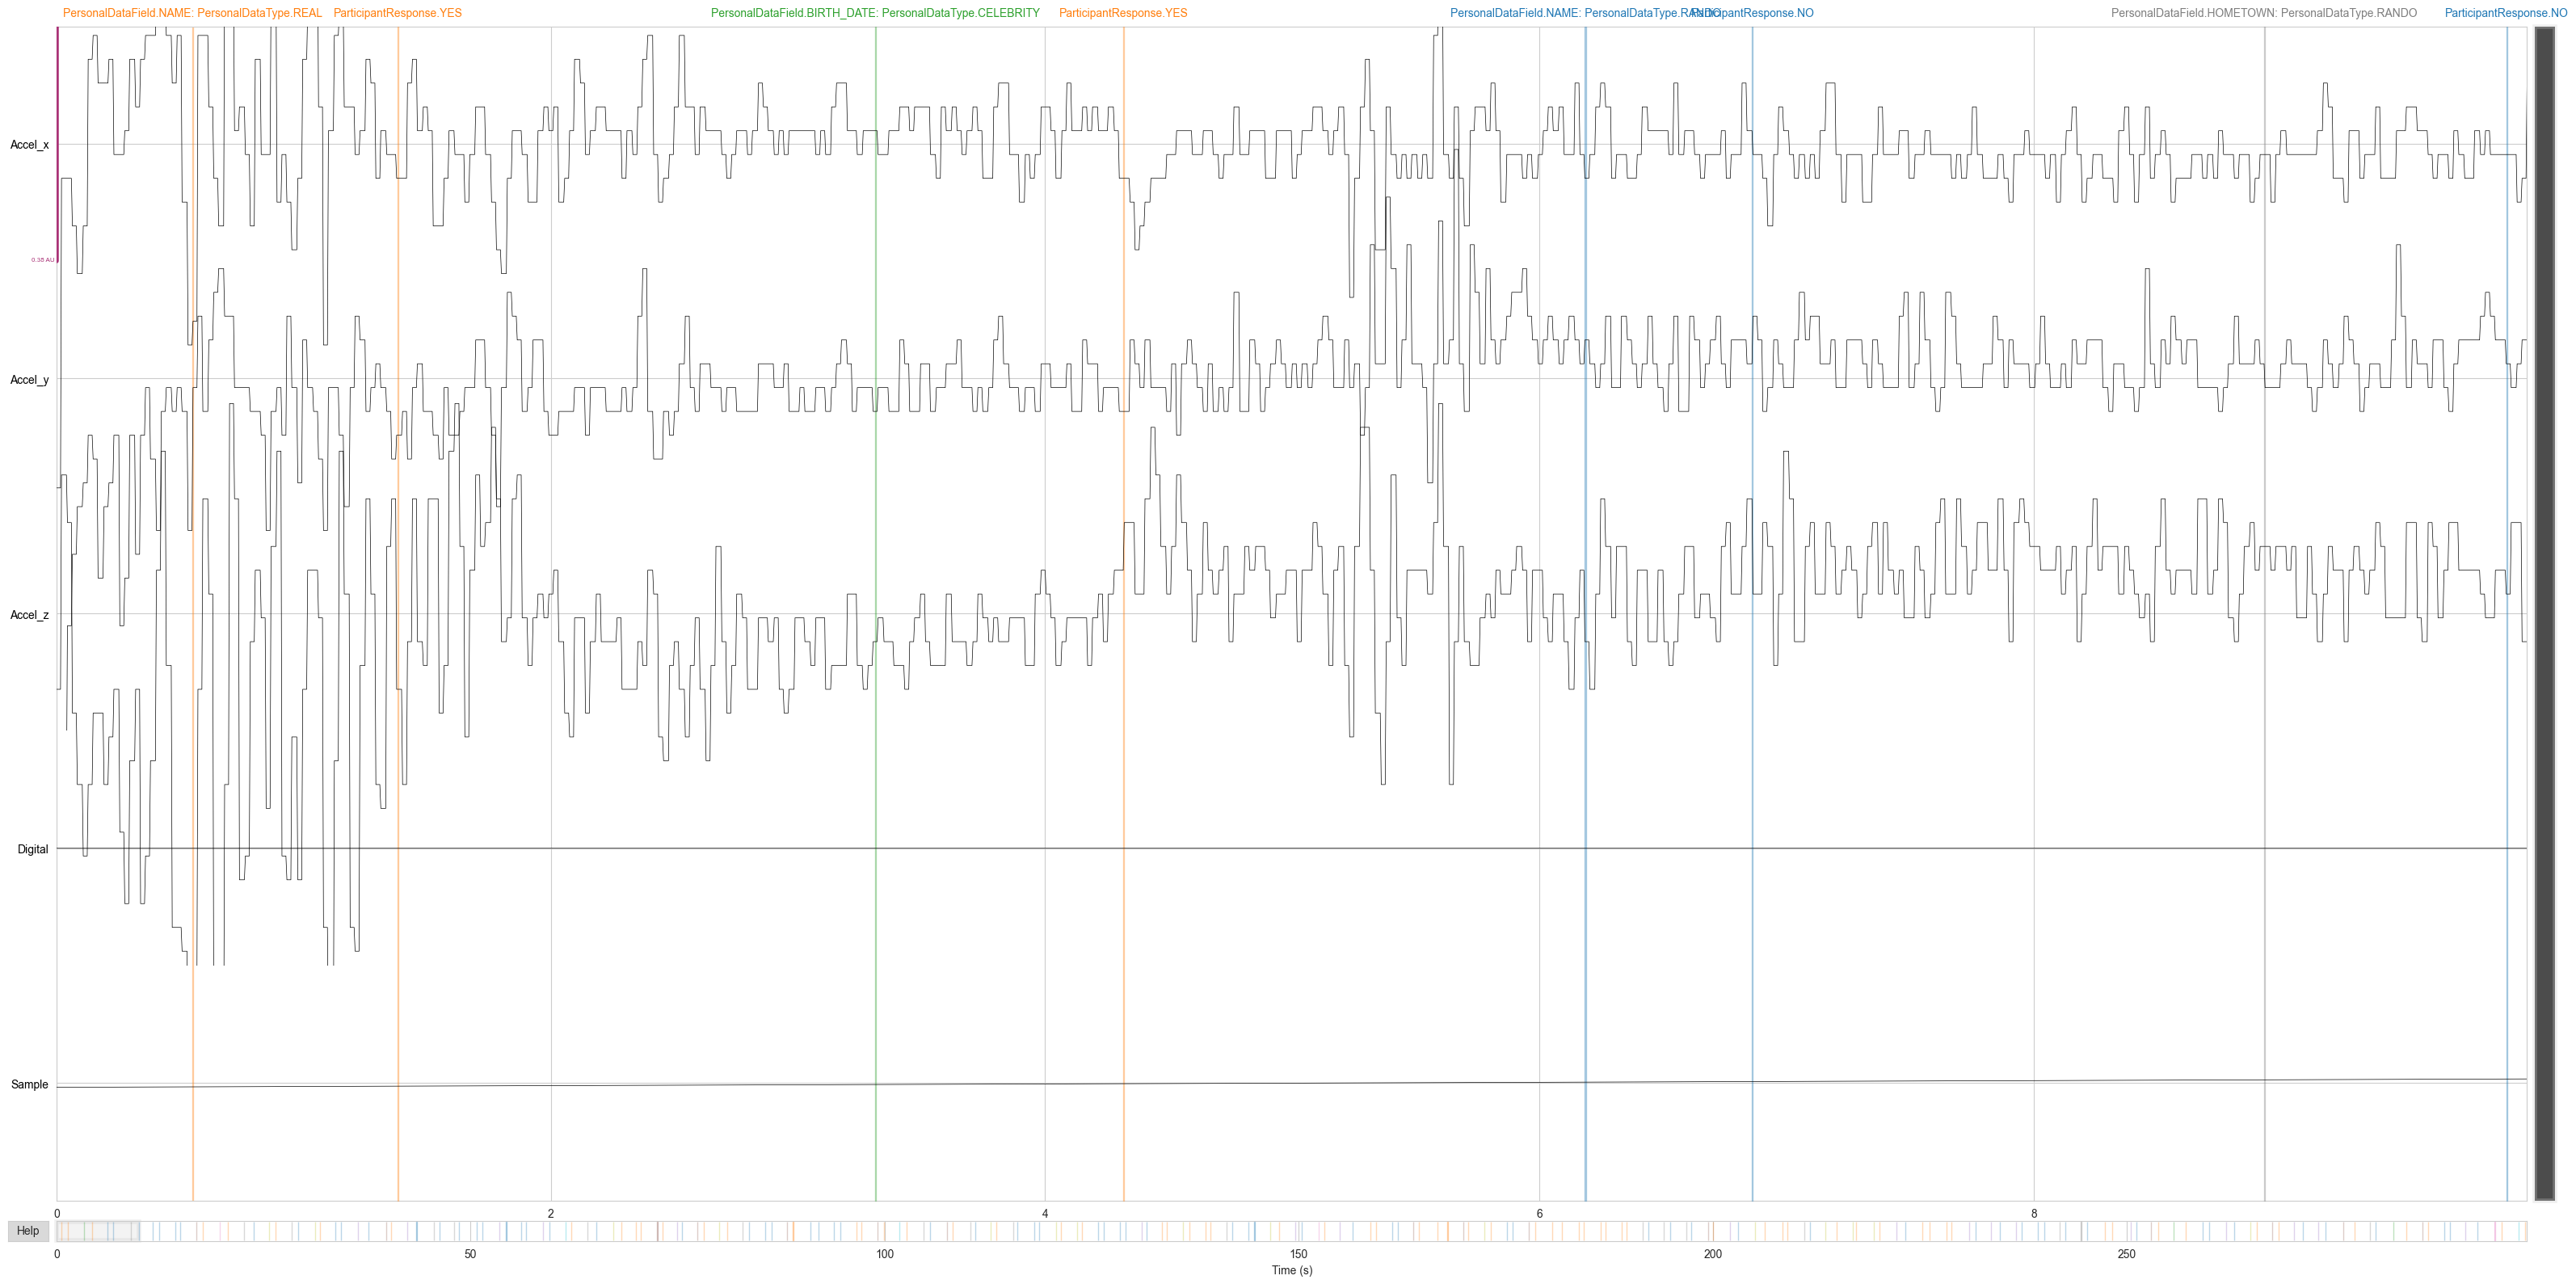

In [8]:
PLOT_DURATION = 10

n_channels = len(raw.ch_names)
split_point = n_channels - 5

raw_filtered = raw.copy()
raw_filtered.filter(l_freq=0.1, h_freq=30.0, picks='eeg', method='iir')
raw_filtered.notch_filter(freqs=50, picks='eeg', method='iir')

print("=" * 80)
print("FILTERED DATA (0.1-30 Hz bandpass + 50 Hz notch)")
print("=" * 80)

first_group = raw_filtered.ch_names[:split_point]
fig1 = raw_filtered.copy().pick_channels(first_group).plot(
    duration=PLOT_DURATION,
    n_channels=len(first_group),
    scalings='auto',
    title=f'{example_participant} - {first_block} (FILTERED - EEG Channels)',
    show=False
)
fig1.set_size_inches(32,16)
plt.tight_layout()
plt.show()

second_group = raw_filtered.ch_names[split_point:]
fig2 = raw_filtered.copy().pick_channels(second_group).plot(
    duration=PLOT_DURATION,
    n_channels=len(second_group),
    scalings='auto',
    title=f'{example_participant} - {first_block} (FILTERED - Auxiliary Channels)',
    show=False
)
fig2.set_size_inches(32, 16)
plt.tight_layout()
plt.show()

Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).


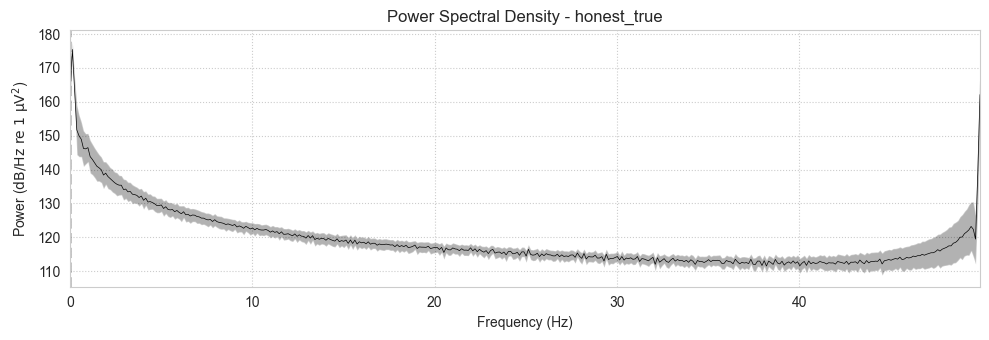

In [9]:
fig = raw.compute_psd(fmax=50).plot(average=True, amplitude=False, 
                                     picks='eeg', show=False)
plt.title(f'Power Spectral Density - {first_block}')
plt.tight_layout()
plt.show()

## 4. Compare Across All Blocks

In [10]:
block_info = []

for block_name, raw_data in participant_data.items():
    events, event_id = loader.get_events_from_raw(raw_data)
    
    block_info.append({
        'block': block_name,
        'duration_sec': raw_data.times[-1],
        'n_events': len(events),
        'n_event_types': len(event_id),
        'sfreq': raw_data.info['sfreq']
    })

block_comparison = pd.DataFrame(block_info)
display(block_comparison)

,block,duration_sec,n_events,n_event_types,sfreq
0,honest_true,298.296,216,11,250.0
1,deceitful_true,329.096,222,12,250.0
2,honest_fake,318.096,218,12,250.0
3,deceitful_fake,314.496,216,11,250.0


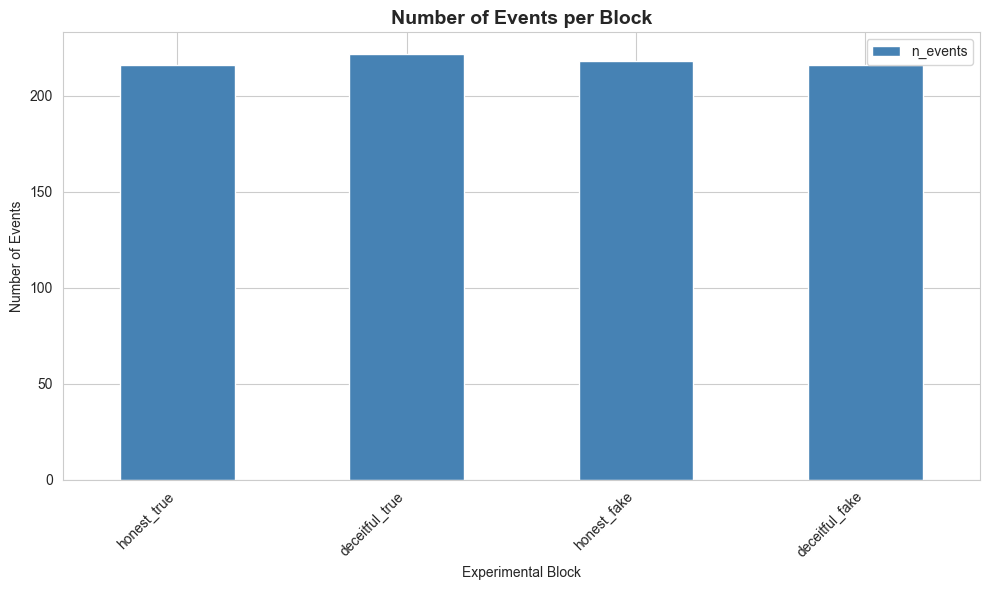

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))
block_comparison.plot(x='block', y='n_events', kind='bar', ax=ax, color='steelblue')
ax.set_title('Number of Events per Block', fontsize=14, fontweight='bold')
ax.set_xlabel('Experimental Block')
ax.set_ylabel('Number of Events')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 5. Signal Quality Assessment

In [12]:
data = raw.get_data() * 1e6

print("Signal Amplitude Statistics (in µV):")
print(f"  Mean: {np.mean(data):.2f} µV")
print(f"  Std: {np.std(data):.2f} µV")
print(f"  Min: {np.min(data):.2f} µV")
print(f"  Max: {np.max(data):.2f} µV")
print(f"  Range: {np.ptp(data):.2f} µV")

Signal Amplitude Statistics (in µV):
  Mean: 101773145537.20 µV
  Std: 72531191394.09 µV
  Min: -841410.58 µV
  Max: 280700348317.62 µV
  Range: 280701189728.20 µV


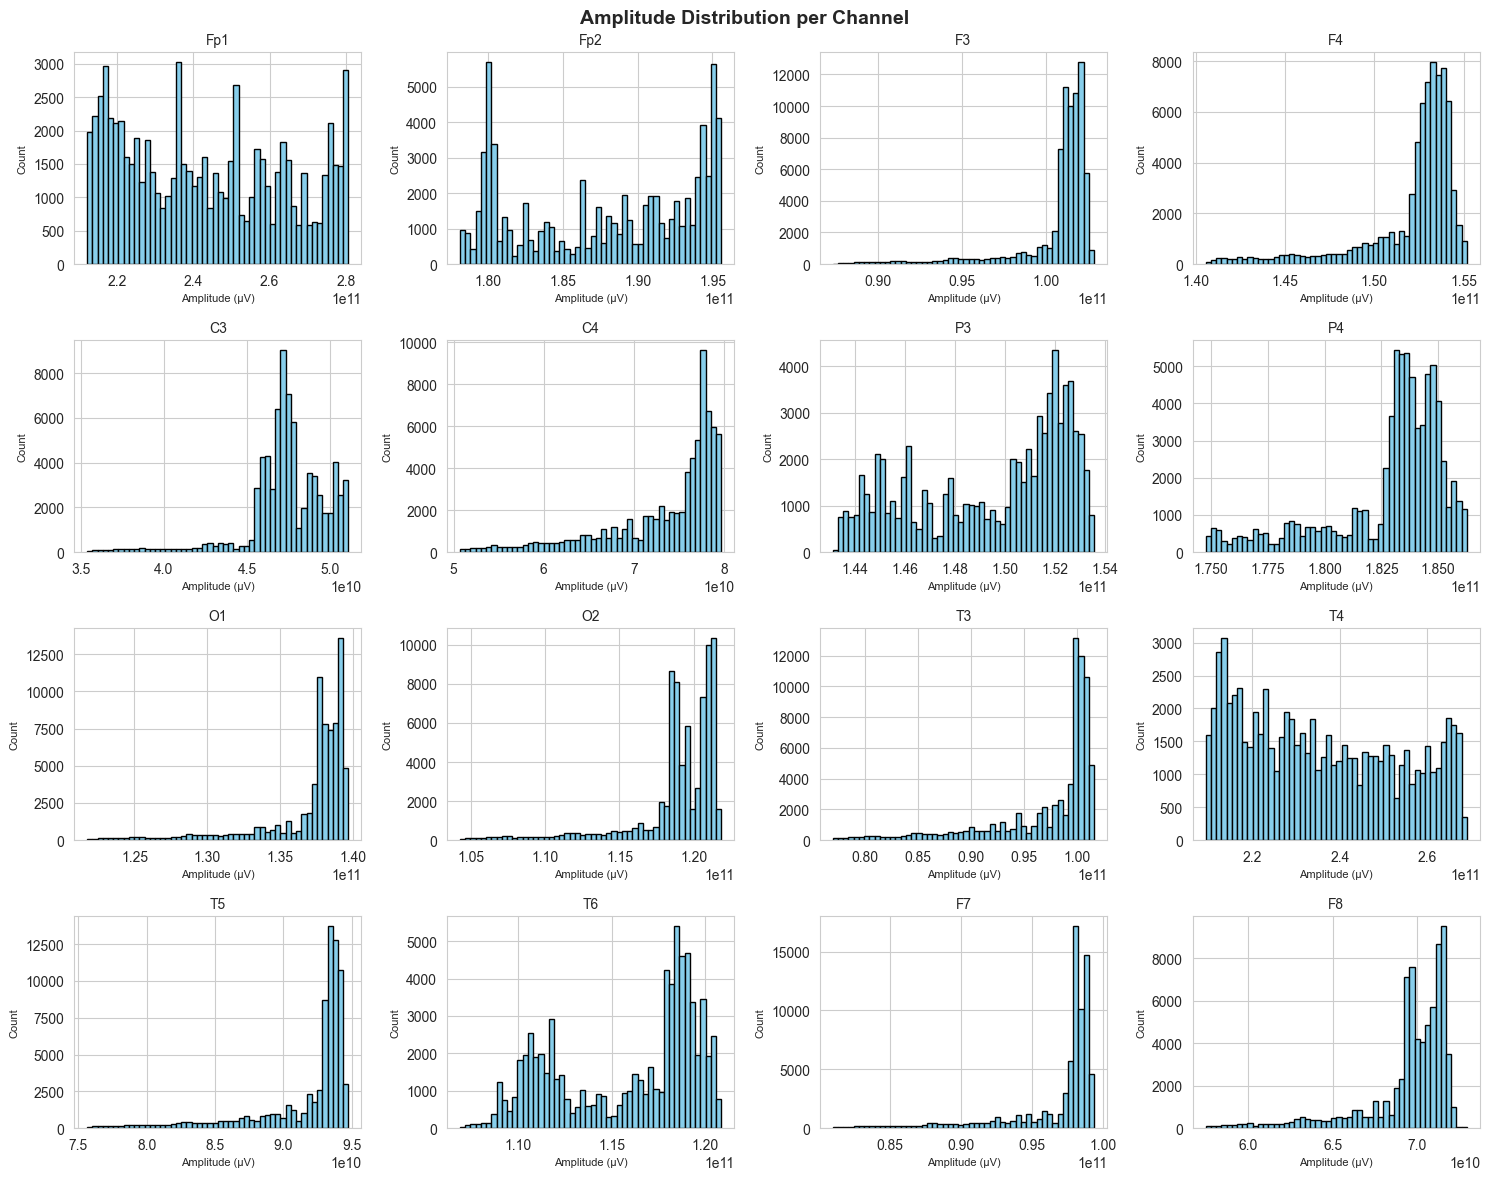

In [13]:
fig, axes = plt.subplots(4, 4, figsize=(15, 12))
axes = axes.flatten()

for idx, ch_name in enumerate(raw.ch_names):
    if idx < len(axes):
        ch_data = data[idx, :]
        axes[idx].hist(ch_data, bins=50, color='skyblue', edgecolor='black')
        axes[idx].set_title(ch_name, fontsize=10)
        axes[idx].set_xlabel('Amplitude (µV)', fontsize=8)
        axes[idx].set_ylabel('Count', fontsize=8)

for idx in range(len(raw.ch_names), len(axes)):
    axes[idx].axis('off')

plt.suptitle('Amplitude Distribution per Channel', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Summary

In [14]:
print("=" * 60)
print("EXPLORATORY DATA ANALYSIS - SUMMARY")
print("=" * 60)
print(f"\n1. Dataset Overview:")
print(f"   - Total participants: {len(summary_df)}")
print(f"   - Participants with complete data: {len(complete_participants)}")
print(f"   - Recording setup: {len(raw.ch_names)} EEG channels @ {raw.info['sfreq']} Hz")

print(f"\n2. Data Quality:")
print(f"   - Signal amplitude range: {np.ptp(data):.2f} µV")
print(f"   - Signal mean amplitude: {np.mean(data):.2f} µV")
print(f"   - Signal std: {np.std(data):.2f} µV")
print(f"   - Events per block: {block_comparison['n_events'].mean():.0f} (avg)")

EXPLORATORY DATA ANALYSIS - SUMMARY

1. Dataset Overview:
   - Total participants: 17
   - Participants with complete data: 17
   - Recording setup: 21 EEG channels @ 250.0 Hz

2. Data Quality:
   - Signal amplitude range: 280701189728.20 µV
   - Signal mean amplitude: 101773145537.20 µV
   - Signal std: 72531191394.09 µV
   - Events per block: 218 (avg)
